In [1]:
# %% Libraries
from fontTools import subset
import os
import scanpy as sc
import numpy as np
from pathlib import Path
import rapids_singlecell as rsc
import pandas as pd
from scipy.sparse import issparse

# %% Setting Paths
MAIN_DIR_NAME = "cosmx_gray"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
CUR_OBJ_V = 'manual-niches'
CUR_OBJ_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{CUR_OBJ_V}.h5ad'

# %% Load the object
comb = sc.read_h5ad(CUR_OBJ_PATH)

In [3]:
# Main object dimensions
print("comb shape:", comb.shape)
print("X shape:", comb.X.shape)
print("number of genes in comb.var:", comb.n_vars)

comb shape: (1065779, 2000)
X shape: (1065779, 2000)
number of genes in comb.var: 2000


(1065779, 2000)

In [2]:
cts = ["airway_epithelium"]

epi = comb[comb.obs["ann_lvl_2"].isin(cts)].copy()
epi


AnnData object with n_obs × n_vars = 214771 × 2000
    obs: 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.Membrane', 'Max.Membrane', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'SplitRatioToLocal', 'NucArea', 'NucAspectRatio', 'Circularity', 'Eccentricity', 'Perimeter', 'Solidity', 'assay_type', 'version', 'Run_Tissue_name', 'Panel', 'cellSegmentationSetId', 'cellSegmentationSetName', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'fa

In [32]:
rsc.pp.neighbors(
    epi,
    use_rep="X_resolvi",   # change this to your actual key
    n_neighbors= 10
)


In [33]:
rsc.tl.umap(epi)


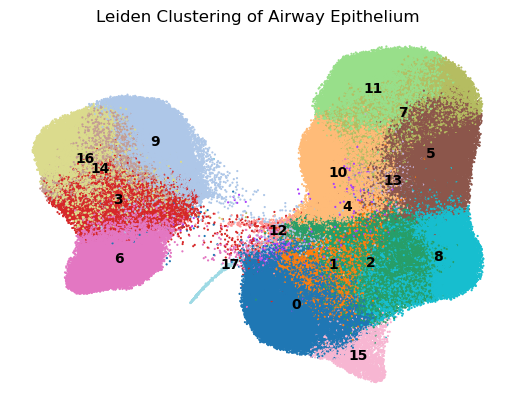

In [37]:
rsc.tl.leiden(epi, resolution=1)

sc.pl.umap(epi, color=["leiden"], size=10, legend_loc="on data", frameon=False, title="Leiden Clustering of Airway Epithelium")

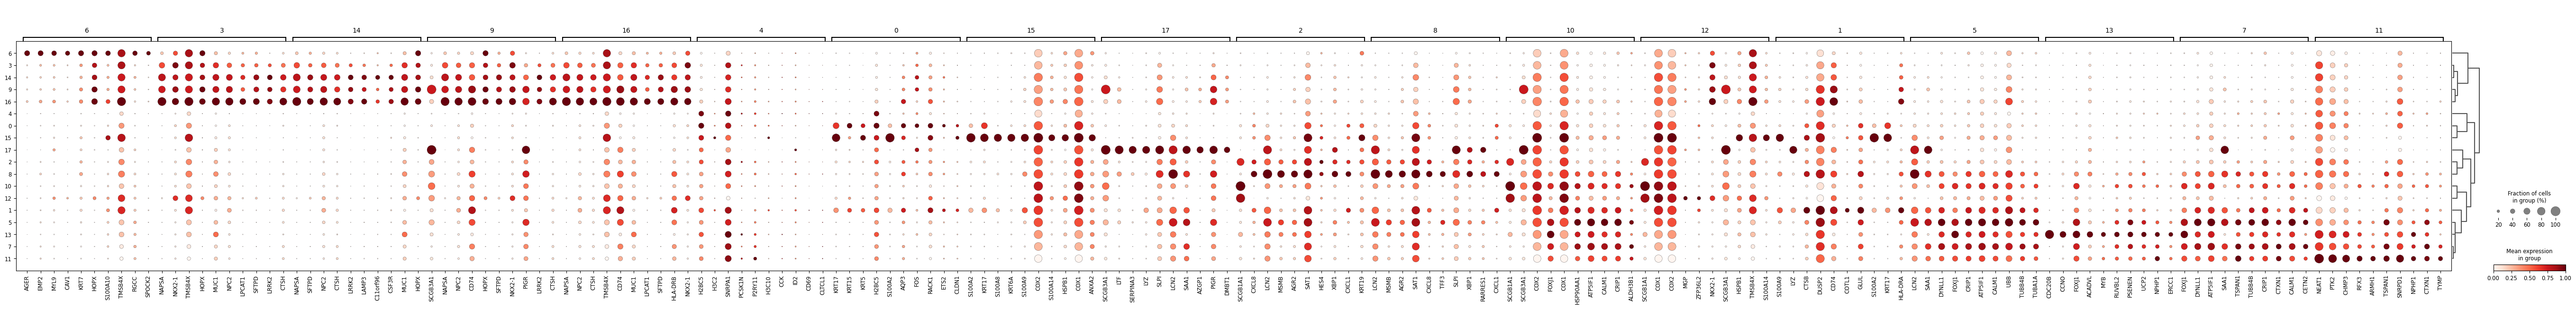

In [38]:
# get marker genes and dotplot

res_name = 'leiden'


rsc.tl.rank_genes_groups(epi, groupby=res_name)

sc.tl.dendrogram(epi, groupby=res_name)

# dotplot
dp = sc.pl.rank_genes_groups_dotplot(
    epi,
    groupby=res_name,
    standard_scale="var",
    n_genes=10, # noramlly 5 
    show=False,
    return_fig=True,   # returns a DotPlot object
)

dp.show()


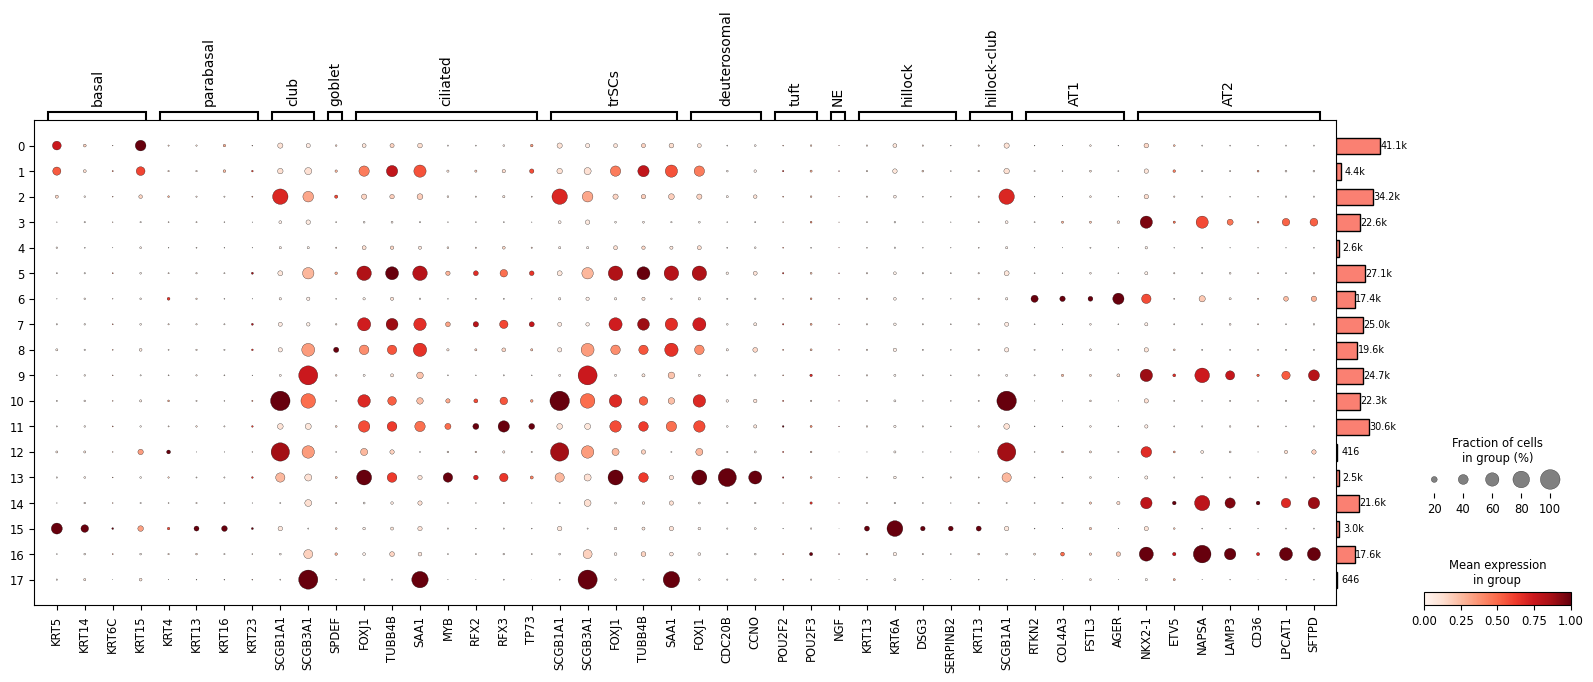

In [39]:
import json
# load canonical markers
all_markers_path = 'code/canonical_markers/epithelial_markers.json'
with open(all_markers_path, 'r') as f:
    all_markers = json.load(f)
# NOTE: check python file, some genes are suposed to be low/not expressed in some cell types



dp = sc.pl.dotplot(
        epi, 
        all_markers, 
        groupby=res_name, 
        standard_scale='var', 
        return_fig=True
    )
# adding cell counts to the dotplot
dp.add_totals().show()


In [46]:
# count 
epi.obs[res_name].value_counts().sort_index()

leiden
0    9662
1    4149
Name: count, dtype: int64